# HAM10000 — Lab Task 02: Effect of Image Filtering
This notebook implements the requirements for Lab Task 02:
1. Retrains the top 3 models: ResNet101+XGBoost, ResNet101 (Fine-tuned), DenseNet121 (Fine-tuned).
2. Uses No Filter (Baseline) + 5 spatial filters (Average, Gaussian, Median, Sharpening, Sobel).
3. Evaluates with Accuracy, Precision, Recall, F1, Macro-F1, Balanced Acc, and AUC.
4. Generates additional analysis: Class distribution, filter examples, confusion matrices, loss/acc curves, and per-class reports.

**Optimizations applied:** GPU acceleration (AMP), Data Augmentation (for accuracy), RAM-caching (for speed).

In [1]:
# ── 1. Installs ────────
try:
    import xgboost, cv2, seaborn
except ImportError:
    import sys
    !{sys.executable} -m pip install -q xgboost opencv-python-headless seaborn scikit-learn matplotlib

In [2]:
# ── 2. Imports & Config ────────
import os, glob, copy, time, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T
from torchvision.models import ResNet101_Weights, DenseNet121_Weights

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, balanced_accuracy_score, classification_report, confusion_matrix)
import xgboost as xgb

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

# Hyperparameters optimized for Kaggle T4 & Accuracy
IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_WORKERS  = 2
MAX_EPOCHS   = 15
PATIENCE     = 5
LR           = 1e-4
WEIGHT_DECAY = 1e-4

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

WORK_DIR = Path("/kaggle/working")
WORK_DIR.mkdir(exist_ok=True)

Device: cuda - Tesla T4


In [3]:
# ── 3. Locate & Load Metadata ────────
meta_candidates = glob.glob("/kaggle/input/**/HAM10000_metadata.csv", recursive=True)
assert meta_candidates, "Dataset not attached. Please attach via 'Add Data' (Search HAM10000)."
metadata_path = meta_candidates[0]
print("Using metadata:", metadata_path)

df = pd.read_csv(metadata_path)
label_names = {
    "akiec": "Actinic keratoses", "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions", "df": "Dermatofibroma",
    "mel": "Melanoma", "nv": "Melanocytic nevi", "vasc": "Vascular lesions",
}
df["label_name"] = df["dx"].map(label_names)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_map = {}
for root, _, files in os.walk("/kaggle/input"):
    for f in files:
        if Path(f).suffix.lower() in image_extensions:
            image_map[Path(f).stem] = str(Path(root) / f)

df["image_path"] = df["image_id"].map(image_map)
df_valid = df[df["image_path"].notna()].copy()
print("Valid images found:", len(df_valid))

CLASSES = sorted(df_valid["dx"].unique().tolist())
NUM_CLASSES = len(CLASSES)
label_to_idx = {c: i for i, c in enumerate(CLASSES)}
print("Classes:", CLASSES)

Using metadata: /kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic/HAM10000_metadata.csv
Valid images found: 10015
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


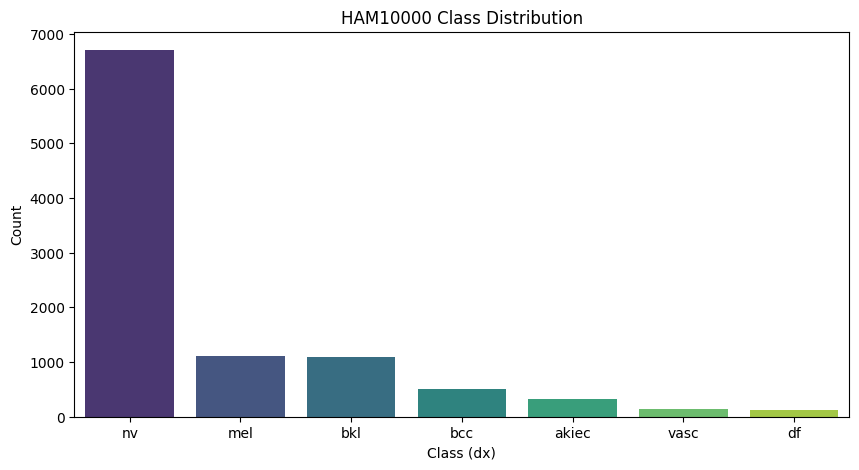

In [4]:
# ── 4. Class Distribution Analysis ────────
plt.figure(figsize=(10, 5))
sns.countplot(data=df_valid, x='dx', order=df_valid['dx'].value_counts().index, palette='viridis')
plt.title("HAM10000 Class Distribution")
plt.xlabel("Class (dx)")
plt.ylabel("Count")
plt.savefig(WORK_DIR / "class_distribution.png", bbox_inches='tight')
plt.show()

In [5]:
# ── 5. Leakage-free Split & Class Weights ────────
lesion_df = df_valid[["lesion_id", "dx"]].drop_duplicates(subset=["lesion_id"]).reset_index(drop=True)

train_lesions, temp_lesions = train_test_split(lesion_df, test_size=0.20, stratify=lesion_df["dx"], random_state=SEED)
val_lesions, test_lesions = train_test_split(temp_lesions, test_size=0.50, stratify=temp_lesions["dx"], random_state=SEED)

train_df = df_valid[df_valid["lesion_id"].isin(train_lesions["lesion_id"])].copy()
val_df   = df_valid[df_valid["lesion_id"].isin(val_lesions["lesion_id"])].copy()
test_df  = df_valid[df_valid["lesion_id"].isin(test_lesions["lesion_id"])].copy()

print(f"Train images: {len(train_df)} | Val images: {len(val_df)} | Test images: {len(test_df)}")

train_labels_all = train_df["dx"].map(label_to_idx).values
class_weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=train_labels_all)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights:", dict(zip(CLASSES, class_weights.round(3))))

Train images: 8020 | Val images: 1005 | Test images: 990
Class weights: {'akiec': np.float64(4.323), 'bcc': np.float64(2.767), 'bkl': np.float64(1.3), 'df': np.float64(13.169), 'mel': np.float64(1.28), 'nv': np.float64(0.213), 'vasc': np.float64(10.416)}


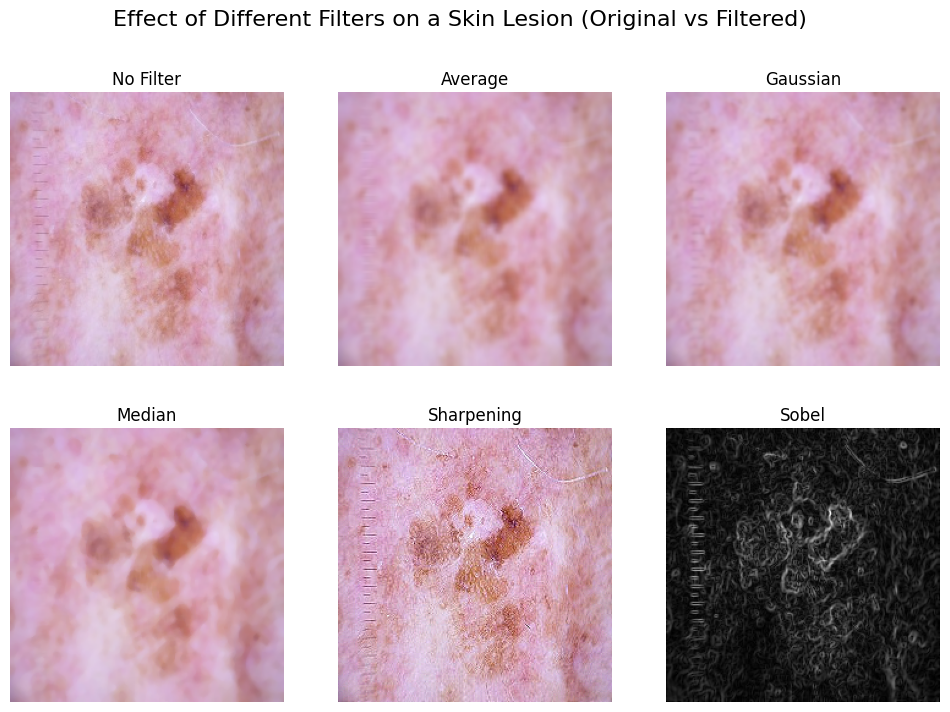

In [6]:
# ── 6. Filter Definitions & Visual Examples ────────
def f_none(img):       return img
def f_average(img):    return cv2.blur(img, (5, 5))
def f_gaussian(img):   return cv2.GaussianBlur(img, (5, 5), 0)
def f_median(img):     return cv2.medianBlur(img, 5)
def f_sharpen(img):
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
    return np.clip(cv2.filter2D(img, -1, kernel), 0, 255).astype(np.uint8)
def f_sobel(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx ** 2 + gy ** 2)
    mag = (mag / (mag.max() + 1e-8) * 255).astype(np.uint8)
    return np.stack([mag, mag, mag], axis=-1)

FILTERS = {
    "No Filter": f_none,
    "Average": f_average,
    "Gaussian": f_gaussian,
    "Median": f_median,
    "Sharpening": f_sharpen,
    "Sobel": f_sobel,
}

# Plot examples for the lab report
sample_img_path = df_valid['image_path'].iloc[0]
sample_img = np.array(Image.open(sample_img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, (name, fn) in enumerate(FILTERS.items()):
    axes[i].imshow(fn(sample_img))
    axes[i].set_title(name)
    axes[i].axis('off')
plt.suptitle("Effect of Different Filters on a Skin Lesion (Original vs Filtered)", fontsize=16)
plt.savefig(WORK_DIR / "filter_examples.png", bbox_inches='tight')
plt.show()

In [7]:
# ── 7. Dataset with Augmentation for Better Accuracy ────────
def build_array_split(dataframe, filter_fn):
    n = len(dataframe)
    imgs = np.zeros((n, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    labels = np.zeros(n, dtype=np.int64)
    for i, row in enumerate(dataframe.itertuples(index=False)):
        img = Image.open(row.image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        imgs[i] = filter_fn(np.array(img))
        labels[i] = label_to_idx[row.dx]
    return imgs, labels

# Data augmentation to prevent overfitting
train_transforms = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15)
])

class ArrayDataset(Dataset):
    def __init__(self, imgs, labels, is_train=False):
        self.imgs = imgs
        self.labels = labels
        self.is_train = is_train

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        arr = self.imgs[idx].astype(np.float32) / 255.0
        tensor = torch.from_numpy(arr).permute(2, 0, 1)
        if self.is_train:
            tensor = train_transforms(tensor)
        tensor = (tensor - IMAGENET_MEAN) / IMAGENET_STD
        return tensor, self.labels[idx]

def make_loader(imgs, labels, is_train, batch_size=BATCH_SIZE):
    ds = ArrayDataset(imgs, labels, is_train=is_train)
    return DataLoader(ds, batch_size=batch_size, shuffle=is_train,
                      num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

In [8]:
# ── 8. Models, Metrics & Plotting Helpers ────────
def get_model(name):
    if name == "resnet101":
        m = torchvision.models.resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    elif name == "densenet121":
        m = torchvision.models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        m.classifier = nn.Linear(m.classifier.in_features, NUM_CLASSES)
    return m.to(DEVICE)

def compute_metrics(y_true, y_pred, y_proba):
    acc  = accuracy_score(y_true, y_pred) * 100
    bacc = balanced_accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0) * 100
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0) * 100
    f1w  = f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100
    f1m  = f1_score(y_true, y_pred, average="macro", zero_division=0) * 100
    try:
        y_true_oh = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
        auc = roc_auc_score(y_true_oh, y_proba, average="macro", multi_class="ovr") * 100
    except Exception:
        auc = float("nan")
    return {"Accuracy": acc, "Balanced Acc": bacc, "Precision": prec, 
            "Recall": rec, "F1-score": f1w, "Macro-F1": f1m, "AUC": auc}

def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(title)
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.savefig(WORK_DIR / filename, bbox_inches='tight')
    plt.close()

def save_class_report(y_true, y_pred, filename):
    rep = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True)
    pd.DataFrame(rep).transpose().to_csv(WORK_DIR / filename)

In [9]:
# ── 9. Training Loop (with Curves) ────────
def evaluate_loader(model, loader, criterion):
    model.eval()
    all_logits, all_labels = [], []
    running_loss = 0.0
    with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16, enabled=DEVICE.type=="cuda"):
        for x, y in loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            out = model(x)
            loss = criterion(out, y)
            running_loss += loss.item() * x.size(0)
            all_logits.append(out.float().cpu())
            all_labels.append(y.cpu())
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    val_loss = running_loss / len(loader.dataset)
    preds = logits.argmax(1).numpy()
    val_f1 = f1_score(labels.numpy(), preds, average="macro", zero_division=0)
    return val_loss, val_f1, logits, labels

def train_model(name, tag, train_loader, val_loader):
    print(f"\n{'='*60}\nTraining {name} | Filter: {tag}\n{'='*60}")
    model = get_model(name)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == "cuda")

    best_f1, best_state, epochs_no_improve = -1.0, None, 0
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        t0 = time.time()
        running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=DEVICE.type=="cuda"):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * x.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_f1, _, _ = evaluate_loader(model, val_loader, criterion)
        scheduler.step(val_f1)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        
        print(f"Epoch {epoch:02d} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Val Macro-F1 {val_f1:.4f} | {time.time()-t0:.1f}s")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch} (Best Val Macro-F1: {best_f1:.4f})")
                break

    model.load_state_dict(best_state)
    torch.save(best_state, WORK_DIR / f"{name}_{tag}_best.pt")
    
    # Save training curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.legend(); plt.title(f"{name} ({tag}) Loss")
    plt.subplot(1, 2, 2)
    plt.plot(history['val_f1'], label='Val Macro-F1', color='green')
    plt.legend(); plt.title(f"{name} ({tag}) Macro-F1")
    plt.savefig(WORK_DIR / f"curves_{name}_{tag}.png", bbox_inches='tight')
    plt.close()
    
    return model

In [10]:
# ── 10. XGBoost Feature Extractor ────────
@torch.no_grad()
def extract_features(extractor, loader):
    feats, labels = [], []
    with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=DEVICE.type=="cuda"):
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            feats.append(extractor(x).float().cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labels)

In [11]:
# ── 11. Main Retraining Loop (Checkpointing Supported) ────────
checkpoint_csv = WORK_DIR / "lab02_results_checkpoint.csv"
if checkpoint_csv.exists():
    print(f"Resuming from {checkpoint_csv}")
    results_df = pd.read_csv(checkpoint_csv)
    results = results_df.to_dict('records')
    completed_filters = set(results_df['Filter'].unique())
else:
    results = []
    completed_filters = set()

for filter_name, filter_fn in FILTERS.items():
    if filter_name in completed_filters:
        print(f"\nSkipping '{filter_name}' - already completed.")
        continue
        
    print(f"\n{'#'*70}\n# FILTER: {filter_name}\n{'#'*70}")
    t_start = time.time()
    tag = filter_name.lower().replace(" ", "_")

    # Arrays
    train_imgs, train_lbls = build_array_split(train_df, filter_fn)
    val_imgs, val_lbls     = build_array_split(val_df, filter_fn)
    test_imgs, test_lbls   = build_array_split(test_df, filter_fn)

    # Loaders
    train_loader_f = make_loader(train_imgs, train_lbls, is_train=True)
    val_loader_f   = make_loader(val_imgs, val_lbls, is_train=False)
    test_loader_f  = make_loader(test_imgs, test_lbls, is_train=False)
    
    criterion_eval = nn.CrossEntropyLoss()

    # -- Model 2: ResNet101 --
    resnet = train_model("resnet101", tag, train_loader_f, val_loader_f)
    _, _, logits, labels = evaluate_loader(resnet, test_loader_f, criterion_eval)
    probs = F.softmax(logits, dim=1).numpy()
    preds = probs.argmax(1)
    
    plot_confusion_matrix(labels.numpy(), preds, f"ResNet101 ({filter_name}) CM", f"cm_resnet_{tag}.png")
    save_class_report(labels.numpy(), preds, f"report_resnet_{tag}.csv")
    m = compute_metrics(labels.numpy(), preds, probs)
    results.append({"Model": "Best Model 2 (ResNet101, fine-tuned)", "Filter": filter_name, **m})

    # -- Model 3: DenseNet121 --
    densenet = train_model("densenet121", tag, train_loader_f, val_loader_f)
    _, _, logits, labels = evaluate_loader(densenet, test_loader_f, criterion_eval)
    probs = F.softmax(logits, dim=1).numpy()
    preds = probs.argmax(1)
    
    plot_confusion_matrix(labels.numpy(), preds, f"DenseNet121 ({filter_name}) CM", f"cm_densenet_{tag}.png")
    save_class_report(labels.numpy(), preds, f"report_densenet_{tag}.csv")
    m = compute_metrics(labels.numpy(), preds, probs)
    results.append({"Model": "Best Model 3 (DenseNet121, fine-tuned)", "Filter": filter_name, **m})

    # -- Model 1: ResNet101 features -> XGBoost --
    print(f"\nTraining XGBoost on ResNet101 features | Filter: {tag}")
    feat_extractor = copy.deepcopy(resnet)
    feat_extractor.fc = nn.Identity()
    feat_extractor.eval().to(DEVICE)

    trainval_imgs = np.concatenate([train_imgs, val_imgs])
    trainval_lbls = np.concatenate([train_lbls, val_lbls])
    trainval_loader_f = make_loader(trainval_imgs, trainval_lbls, is_train=False)

    X_trainval, y_trainval = extract_features(feat_extractor, trainval_loader_f)
    X_test, y_test = extract_features(feat_extractor, test_loader_f)

    scaler = StandardScaler().fit(X_trainval)
    X_trainval_s = scaler.transform(X_trainval)
    X_test_s = scaler.transform(X_test)

    xgb_clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", num_class=NUM_CLASSES,
        eval_metric="mlogloss", tree_method="hist",
        device="cuda" if DEVICE.type == "cuda" else "cpu",
        random_state=SEED, n_jobs=-1
    )
    xgb_clf.fit(X_trainval_s, y_trainval)

    probs = xgb_clf.predict_proba(X_test_s)
    preds = probs.argmax(1)
    
    plot_confusion_matrix(y_test, preds, f"XGBoost ({filter_name}) CM", f"cm_xgb_{tag}.png")
    save_class_report(y_test, preds, f"report_xgb_{tag}.csv")
    m = compute_metrics(y_test, preds, probs)
    results.append({"Model": "Best Model 1 (ResNet101 features + XGBoost)", "Filter": filter_name, **m})

    # Checkpoint
    pd.DataFrame(results).to_csv(checkpoint_csv, index=False)
    print(f"Filter '{filter_name}' done in {(time.time() - t_start)/60:.1f} min")

    del train_imgs, val_imgs, test_imgs, trainval_imgs
    del resnet, densenet, feat_extractor
    torch.cuda.empty_cache()


######################################################################
# FILTER: No Filter
######################################################################

Training resnet101 | Filter: no_filter
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:00<00:00, 210MB/s]


Epoch 01 | Train Loss 1.3311 | Val Loss 0.9061 | Val Macro-F1 0.5211 | 76.2s
Epoch 02 | Train Loss 0.6616 | Val Loss 0.7745 | Val Macro-F1 0.6051 | 58.1s
Epoch 03 | Train Loss 0.4475 | Val Loss 0.7576 | Val Macro-F1 0.6107 | 57.5s
Epoch 04 | Train Loss 0.3132 | Val Loss 0.7055 | Val Macro-F1 0.6735 | 57.3s
Epoch 05 | Train Loss 0.2898 | Val Loss 0.6976 | Val Macro-F1 0.6399 | 57.8s
Epoch 06 | Train Loss 0.2237 | Val Loss 0.7089 | Val Macro-F1 0.7034 | 57.5s
Epoch 07 | Train Loss 0.1842 | Val Loss 0.6470 | Val Macro-F1 0.7144 | 57.5s
Epoch 08 | Train Loss 0.1646 | Val Loss 0.7205 | Val Macro-F1 0.7149 | 57.7s
Epoch 09 | Train Loss 0.1244 | Val Loss 0.7230 | Val Macro-F1 0.6916 | 57.7s
Epoch 10 | Train Loss 0.1068 | Val Loss 0.8644 | Val Macro-F1 0.6513 | 57.7s
Epoch 11 | Train Loss 0.0944 | Val Loss 0.7825 | Val Macro-F1 0.6975 | 57.7s
Epoch 12 | Train Loss 0.0620 | Val Loss 0.7537 | Val Macro-F1 0.7244 | 57.6s
Epoch 13 | Train Loss 0.0372 | Val Loss 0.8582 | Val Macro-F1 0.7351 | 57.6s

100%|██████████| 30.8M/30.8M [00:00<00:00, 217MB/s]


Epoch 01 | Train Loss 1.1234 | Val Loss 1.0476 | Val Macro-F1 0.4920 | 60.9s
Epoch 02 | Train Loss 0.6536 | Val Loss 0.7293 | Val Macro-F1 0.6202 | 41.0s
Epoch 03 | Train Loss 0.4771 | Val Loss 0.6156 | Val Macro-F1 0.6563 | 41.6s
Epoch 04 | Train Loss 0.3991 | Val Loss 0.6336 | Val Macro-F1 0.6836 | 41.1s
Epoch 05 | Train Loss 0.3364 | Val Loss 0.5883 | Val Macro-F1 0.6913 | 41.2s
Epoch 06 | Train Loss 0.2771 | Val Loss 0.6627 | Val Macro-F1 0.6823 | 41.4s
Epoch 07 | Train Loss 0.2290 | Val Loss 0.5739 | Val Macro-F1 0.7135 | 41.4s
Epoch 08 | Train Loss 0.2083 | Val Loss 0.6443 | Val Macro-F1 0.6922 | 41.3s
Epoch 09 | Train Loss 0.1735 | Val Loss 0.6423 | Val Macro-F1 0.6978 | 41.2s
Epoch 10 | Train Loss 0.1471 | Val Loss 0.6422 | Val Macro-F1 0.7066 | 41.2s
Epoch 11 | Train Loss 0.1033 | Val Loss 0.5586 | Val Macro-F1 0.7434 | 41.3s
Epoch 12 | Train Loss 0.0696 | Val Loss 0.5919 | Val Macro-F1 0.7389 | 41.4s
Epoch 13 | Train Loss 0.0691 | Val Loss 0.5999 | Val Macro-F1 0.7420 | 41.3s

In [12]:
# ── 12. Final Results Table ────────
results_df = pd.DataFrame(results)

model_order = ["Best Model 1 (ResNet101 features + XGBoost)",
               "Best Model 2 (ResNet101, fine-tuned)",
               "Best Model 3 (DenseNet121, fine-tuned)"]
filter_order = list(FILTERS.keys())

results_df["Model"] = pd.Categorical(results_df["Model"], categories=model_order, ordered=True)
results_df["Filter"] = pd.Categorical(results_df["Filter"], categories=filter_order, ordered=True)
results_df = results_df.sort_values(["Model", "Filter"]).reset_index(drop=True)
results_df = results_df.round(2)

results_df.to_csv(WORK_DIR / "final_lab02_results.csv", index=False)
display(results_df)

,Model,Filter,Accuracy,Balanced Acc,Precision,Recall,F1-score,Macro-F1,AUC
0,Best Model 1 (ResNet101 features + XGBoost),No Filter,84.85,66.64,84.61,84.85,84.58,70.45,95.52
1,Best Model 1 (ResNet101 features + XGBoost),Average,83.84,66.76,83.72,83.84,83.65,70.63,95.51
2,Best Model 1 (ResNet101 features + XGBoost),Gaussian,83.94,66.42,83.58,83.94,83.60,70.49,95.40
3,Best Model 1 (ResNet101 features + XGBoost),Median,84.75,66.98,84.30,84.75,84.40,69.55,95.10
4,Best Model 1 (ResNet101 features + XGBoost),Sharpening,84.34,67.34,84.29,84.34,84.07,70.47,95.76
5,Best Model 1 (ResNet101 features + XGBoost),Sobel,78.48,52.20,77.33,78.48,77.62,55.32,90.89
6,"Best Model 2 (ResNet101, fine-tuned)",No Filter,84.34,69.29,85.03,84.34,84.53,70.54,94.28
7,"Best Model 2 (ResNet101, fine-tuned)",Average,82.73,70.52,83.33,82.73,82.95,71.08,94.25
8,"Best Model 2 (ResNet101, fine-tuned)",Gaussian,81.31,67.15,83.27,81.31,81.91,68.24,94.52
9,"Best Model 2 (ResNet101, fine-tuned)",Median,82.93,68.16,83.78,82.93,83.15,69.65,93.16
